In [9]:
#1. 라이브러리 설치
def read_library():

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import scipy.stats as stats
    import statsmodels.formula.api as smf
    import statsmodels.api as sm
    import platform
    import ast

    pd.set_option("display.float_format", "{:.2f}".format)

    if platform.system() == "Darwin":
        plt.rcParams["font.family"] = "AppleGothic"
    elif platform.system() == "Windows":
        plt.rcParams["font.family"] = "Malgun Gothic"
    else:
        plt.rcParams["font.family"] = "NanumGothic"

    return pd, np, plt, sns, stats, smf, sm, ast


#2. 데이터 로드
def load_data(pd):

    df = pd.read_csv("../원본 데이터 셋/2025_Airbnb_NYC_listings.csv")

    print("데이터 크기:", df.shape)
    print(df.head())

    return df


#3. 데이터 확인
def overview(df):

    print(df.info())
    print(df.describe())


#4. 가짜 결측 확인
def fake_null(df):

    fake_null = ['NaN','None','none','NULL','null','N/A','na','']

    fake_counts = df.isin(fake_null).sum()

    print(fake_counts[fake_counts > 0])


#5. Datetime 변환
def datetime(df, pd):

    date_cols = [
        "host_since",
        "first_review",
        "last_review",
        "calendar_last_scraped"
    ]

    df[date_cols] = df[date_cols].apply(pd.to_datetime, errors="coerce")

    return df


#6. 가격 컬럼 전처리
def price_clean(df, np):

    df["price"] = (
        df["price"]
        .astype(str)
        .str.replace("$","",regex=False)
        .str.replace(",","",regex=False)
        .astype(float)
    )

    df["price_log"] = np.log1p(df["price"])

    return df


#7. 리뷰관련 컬럼 결측치 처리
def missing(df):

    review_cols = [
        "number_of_reviews",
        "number_of_reviews_ltm",
        "number_of_reviews_l30d",
        "reviews_per_month",
        "estimated_occupancy_l365d"
    ]

    df[review_cols] = df[review_cols].fillna(0)

    df["review_scores_rating"] = df["review_scores_rating"].fillna(
        df["review_scores_rating"].median()
    )

    df["bathrooms"] = df["bathrooms"].fillna(0)
    df["bedrooms"] = df["bedrooms"].fillna(0)
    df["beds"] = df["beds"].fillna(0)

    return df


#9. Amenities Count
def amenity_count(x):
    try:
        return len(ast.literal_eval(x))
    except:
        return 0


#8. 파생컬럼 생성
def feature_engineering(df, np):

    df["room_capacity"] = (
        df["bathrooms"] +
        df["bedrooms"] +
        df["beds"]
    )

    df["occupancy_rate"] = (
        df["estimated_occupancy_l365d"] / 365
    )

    df["log_reviews"] = np.log1p(df["number_of_reviews"])

    df["amenities_len"] = df["amenities"].apply(amenity_count)

    return df


#10. 룸타입 맵핑
def step10_regulation(df):

    property_map = {

        "Room in hotel": "Lodging",
        "Room in boutique hotel": "Lodging",

        "Entire rental unit": "Residential",
        "Private room in rental unit": "Residential",
        "Private room in home": "Residential",
        "Entire home": "Residential",
        "Entire condo": "Residential"
    }

    df["property_regulation_type"] = (
        df["property_type"]
        .map(property_map)
        .fillna("Other")
    )

    return df


#11. 규제 범위 나누기
def step11_legal_filter(df):

    df["legal_flag"] = "Legal"

    df.loc[
        (df["property_regulation_type"]=="Residential") &
        (df["room_type"]=="Entire home/apt") &
        (df["minimum_nights"] < 30),
        "legal_flag"
    ] = "Illegal"

    df = df[
        ((df['property_regulation_type'] == 'Residential') & (df['legal_flag'] == 'Legal'))
        | (df['property_regulation_type'] == 'Lodging')
    ]

    return df


#12 Strategy 정의
def strategy(row):

    if row["property_regulation_type"]=="Residential":

        if row["minimum_nights"] < 30:
            return "Residential_short_term"
        else:
            return "Residential_long_term"

    else:
        return "Hotel"


#strategy 컬럼 생성
def create_strategy(df):

    df["rental_strategy"] = df.apply(strategy, axis=1)

    return df


#13 매출 공식 검증
def revenue_verification(df):

    df["calc_revenue"] = (
        df["price"] *
        df["estimated_occupancy_l365d"]
    )

    print(
        "Revenue match:",
        (df["calc_revenue"]==df["estimated_revenue_l365d"]).mean()
    )

    return df


#26 Investment Simulator
def recommend_investor(df, persona, initial_investment, top_n=10):

    filtered = df[
        (df['rental_strategy'] == persona['rental_strategy']) &
        (df['room_type'] == persona['room_type']) &
        (df['neighbourhood_group_cleansed'] == persona['neighbourhood_group_cleansed'])
    ]

    if filtered.empty:
        print("조건에 맞는 데이터가 없습니다.")
        return pd.DataFrame()

    filtered = filtered[
        filtered["estimated_revenue_l365d"] > 0
    ]

    if filtered.empty:
        print("매출 데이터가 있는 숙소가 없습니다.")
        return pd.DataFrame()

    segment_summary = filtered.groupby(
        ['room_type', 'accommodates']
    ).agg(

        median_price=('price', 'median'),
        median_occupancy_rate=('occupancy_rate', 'median'),
        median_revenue=('estimated_revenue_l365d', 'median'),
        총매출=('estimated_revenue_l365d', 'sum'),
        listing_count=('price', 'count'),
        median_reviews=('number_of_reviews', 'median')

    ).reset_index()

    segment_summary = segment_summary[
        segment_summary['listing_count'] >= 50
    ]

    if segment_summary.empty:
        print("표본수 50개 이상 세그먼트 없음")
        return pd.DataFrame()

    전체매물수 = segment_summary['listing_count'].sum()
    전체매출 = segment_summary['총매출'].sum()

    segment_summary['매물비중'] = (
        segment_summary['listing_count'] / 전체매물수
    )

    segment_summary['매출비중'] = (
        segment_summary['총매출'] / 전체매출
    )

    segment_summary['수익효율지수'] = (
        segment_summary['매출비중'] /
        segment_summary['매물비중']
    )

    # 시장 포지션
    경쟁기준 = segment_summary['listing_count'].median()

    def 시장분류(row):

        경쟁높음 = row['listing_count'] >= 경쟁기준
        효율높음 = row['수익효율지수'] >= 1

        if (not 경쟁높음) and 효율높음:
            return "블루오션"
        elif 경쟁높음 and 효율높음:
            return "레드오션(Mainstream)"
        elif 경쟁높음 and (not 효율높음):
            return "헬오션(Avoid)"
        else:
            return "저수요 틈새시장"

    segment_summary['시장포지션'] = segment_summary.apply(시장분류, axis=1)

    segment_summary['추정 월 매출'] = (
        segment_summary['median_revenue'] / 12
    )

    segment_summary['추정 관리/유지비'] = (
        segment_summary['추정 월 매출'] * 0.25
    )

    segment_summary['추정 월 이익'] = (
        segment_summary['추정 월 매출'] -
        segment_summary['추정 관리/유지비']
    )

    segment_summary['추정 회수기간(월)'] = np.where(
        segment_summary['추정 월 이익'] > 0,
        initial_investment / segment_summary['추정 월 이익'],
        np.nan
    )

    segment_summary['투자매력도점수'] = (
        segment_summary['수익효율지수'] *
        segment_summary['추정 월 이익']
    )

    top_segments = segment_summary.sort_values(
        by='투자매력도점수',
        ascending=False
    ).head(top_n)

    return top_segments


#---------------------------------------------------------
# persona 생성
#---------------------------------------------------------
def create_persona():

    rental_strategy = input(
        "1. 운영형태 입력 (Residential_short_term / Residential_long_term / Hotel): "
    )

    room_type = input(
        "2. 숙소타입 입력 (Entire home/apt | Private room | Shared room | Hotel room): "
    )

    borough = input(
        "3. 지역구 입력 (Manhattan / Brooklyn / Queens / Bronx / Staten Island): "
    )

    initial_investment = int(
        input("4. 투자자본 입력 ($): ")
    )

    persona = {
        "rental_strategy": rental_strategy,
        "room_type": room_type,
        "neighbourhood_group_cleansed": borough
    }

    return persona, initial_investment


#---------------------------------------------------------
# 실행 코드
#---------------------------------------------------------

pd, np, plt, sns, stats, smf, sm, ast = read_library()

df = load_data(pd)

overview(df)

df = datetime(df, pd)
df = price_clean(df, np)
df = missing(df)
df = feature_engineering(df, np)

df = step10_regulation(df)
df = step11_legal_filter(df)
df = create_strategy(df)

persona, initial_investment = create_persona()

result = recommend_investor(df, persona, initial_investment, top_n=10)

result

데이터 크기: (22308, 73)
   Unnamed: 0     id       source  \
0           0  36121  city scrape   
1           1  36647  city scrape   
2           2  38663  city scrape   
3           3  38833  city scrape   
4           4  39282  city scrape   

                                                name  \
0                 Lg Rm in Historic Prospect Heights   
1  1 Bedroom & your own Bathroom, Elevator Apartment   
2                   Luxury Brownstone in Boerum Hill   
3                 Spectacular West Harlem Garden Apt   
4                    “Work-from-home” from OUR home.   

                                         description  \
0  Cozy space share in the heart of a great neigh...   
1  Private bedroom with your own bathroom in a 2 ...   
2  Beautiful, large home in great hipster neighbo...   
3  This is a very large and unique  space. An inc...   
4  *Monthly Discount will automatically apply <br...   

                               neighborhood_overview  host_id host_name  \
0  Full 

""


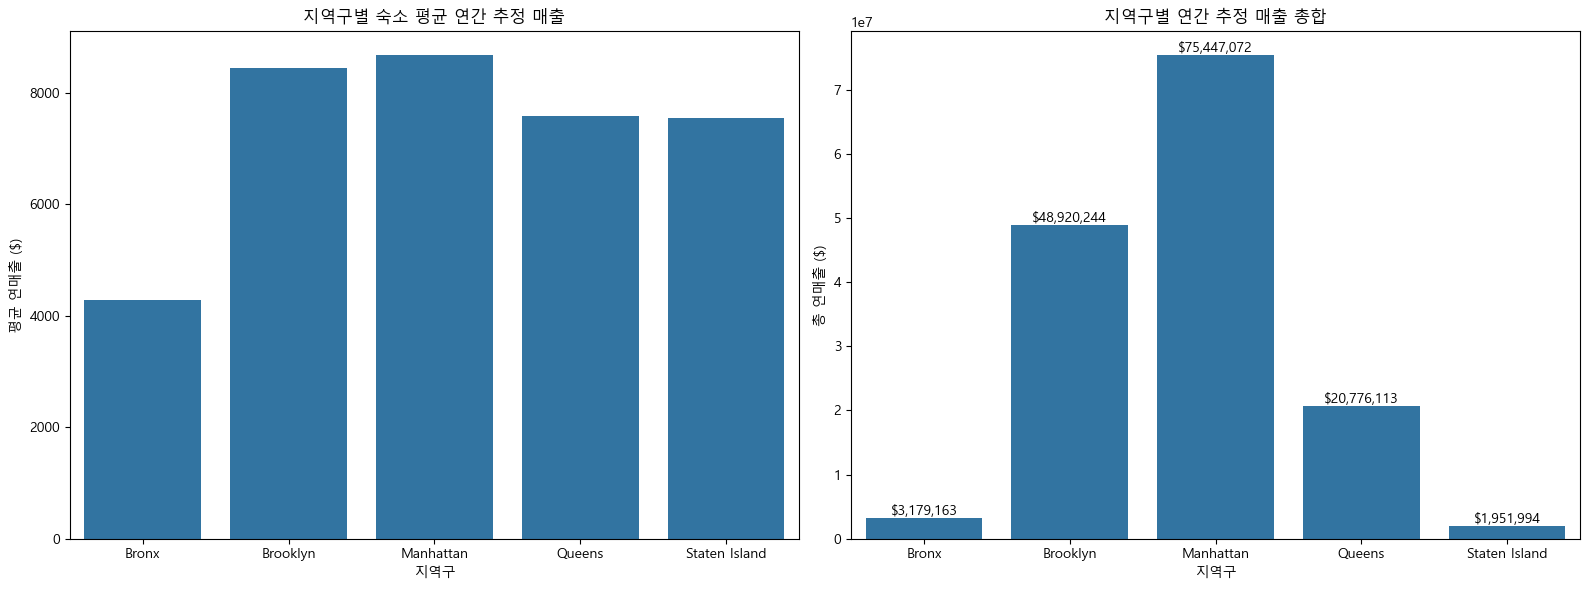

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 지역구별 매출 집계
revenue_summary = df.groupby("neighbourhood_group_cleansed").agg(
    평균_연매출=("estimated_revenue_l365d", "mean"),
    총_연매출=("estimated_revenue_l365d", "sum"),
    숙소수=("estimated_revenue_l365d", "count")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16,6))


# 1️⃣ 평균 연매출 그래프
sns.barplot(
    data=revenue_summary,
    x="neighbourhood_group_cleansed",
    y="평균_연매출",
    ax=axes[0]
)

axes[0].set_title("지역구별 숙소 평균 연간 추정 매출")
axes[0].set_xlabel("지역구")
axes[0].set_ylabel("평균 연매출 ($)")


# 2️⃣ 총 연매출 그래프
sns.barplot(
    data=revenue_summary,
    x="neighbourhood_group_cleansed",
    y="총_연매출",
    ax=axes[1]
)

axes[1].set_title("지역구별 연간 추정 매출 총합")
axes[1].set_xlabel("지역구")
axes[1].set_ylabel("총 연매출 ($)")


# 🔹 바 위에 $ + 천단위 콤마 표시
for p in axes[1].patches:
    value = p.get_height()
    axes[1].text(
        p.get_x() + p.get_width()/2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

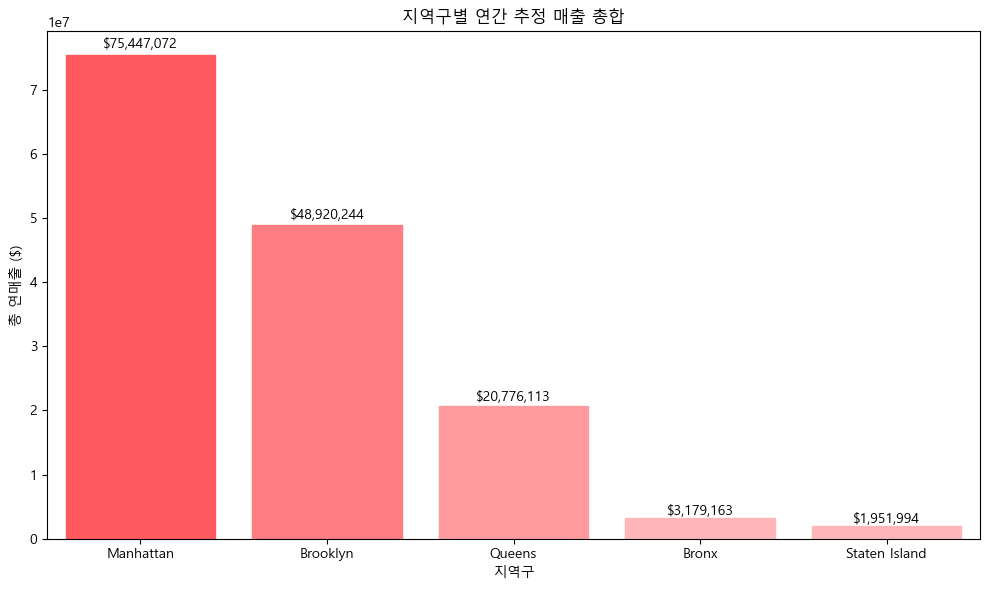

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 지역구별 총 연매출 계산
revenue_sum = (
    df.groupby("neighbourhood_group_cleansed")["estimated_revenue_l365d"]
    .sum()
    .reset_index()
)

# 매출 기준 내림차순 정렬
revenue_sum = revenue_sum.sort_values(
    by="estimated_revenue_l365d",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(10,6))

# 그래프 생성
ax = sns.barplot(
    data=revenue_sum,
    x="neighbourhood_group_cleansed",
    y="estimated_revenue_l365d",
    color="lightgrey"
)

# 지정 색상 (진 → 연)
colors = ["#FF5A5F", "#FF7E82", "#FF9B9E", "#FFB7BA"]

bars = ax.patches

# 색 적용 (데이터 개수와 맞게)
for i in range(len(bars)):
    bars[i].set_color(colors[min(i, len(colors)-1)])

plt.title("지역구별 연간 추정 매출 총합")
plt.xlabel("지역구")
plt.ylabel("총 연매출 ($)")

# 바 위 숫자 표시 ($ + 천단위 콤마)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height * 1.01,  # bar 바로 위
        f"${height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

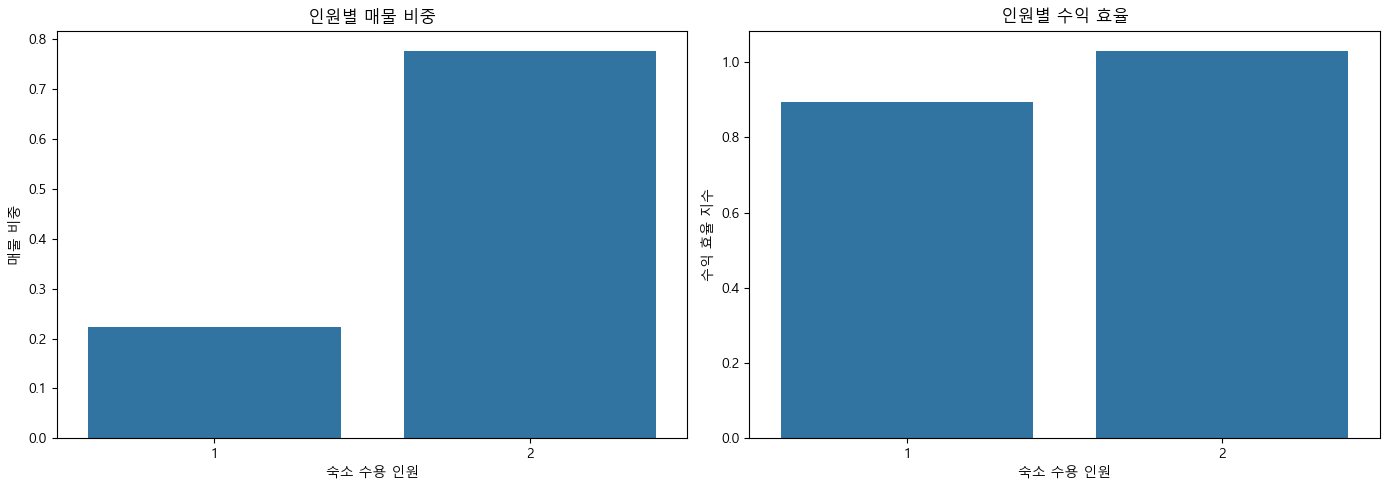

In [ ]:
segment_summary = result.copy()

# 그래프 2개 한 화면에 배치
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# -----------------------------
# 1. 인원별 매물 비중
# -----------------------------
sns.barplot(
    data=segment_summary,
    x='accommodates',
    y='매물비중',
    ax=axes[0]
)

axes[0].set_title("인원별 매물 비중")
axes[0].set_xlabel("숙소 수용 인원")
axes[0].set_ylabel("매물 비중")

# -----------------------------
# 2. 인원별 수익 효율
# -----------------------------
sns.barplot(
    data=segment_summary,
    x='accommodates',
    y='수익효율지수',
    ax=axes[1]
)

axes[1].set_title("인원별 수익 효율")
axes[1].set_xlabel("숙소 수용 인원")
axes[1].set_ylabel("수익 효율 지수")

plt.tight_layout()
plt.show()

# 예시 시나리오
| 항목 | 시나리오 1: 브루클린 | 시나리오 2: 맨해튼 | 시나리오 3: 퀸즈 (최적안) |
|-----|------------------|------------------|------------------|
| 페르소나 | 단체 손님 전문 펜션지기 | 리스크 관리 전략가 | 3개월 컷 프로 부업러 |
| 투자 원금 | $25,000 (약 3,300만 원) | $30,000 (약 4,000만 원) | $15,000 (약 2,000만 원) |
| 숙소 유형 | Entire home (독채 전체) | Private room (개인실) | Private room (개인실) |
| 핵심 타겟 | 14인 이상 대규모 단체 | 5인 가족 및 비즈니스 팀 | 6인 우정 여행 / 소가족 |
| 평균 가격 | $374.00 | $385.50 | $269.00 |
| 시장 포지션 | 초블루오션 (숙소 5개뿐) | 블루오션 (숙소 4개뿐) | 블루오션 (숙소 8개뿐) |
| 월 순이익 | $2,766.58 | $3,029.87 | $4,228.46 |
| 회수 기간 | 9.04개월 | 9.9개월 | **3.55개월 (압도적)** |
| 한 줄 전략 | "레드오션 독채들 사이에서 '대형 인원'으로만 승부한다." | "비싼 맨해튼에서 1인실 버리고 5인실로 단가 싸움한다." | "가장 적은 돈 투자해서 가장 빨리 뽑고 돈 복사 시작한다." |